# 발음 스타일별 음성 분석 파이프라인 (Accent Style Analysis)

**신호 및 시스템 - Term Project**

문장: `I think this signal processing project is really interesting.`

이 노트북은 같은 영어 문장을 **세 가지 발음 스타일**(미국식 / 한국식 / 일본식)로 발화한 음성을
Fourier 분석 도구로 비교하고, 한국식·일본식 발음을 미국식에 가깝게 변환하는 실험을 수행합니다.

### 설계 원칙
- **파일명만 바꾸면** Papago 저장본이든 직접 녹음한 음성이든 똑같이 동작합니다.
- 단어 경계 시간을 **손으로 적지 않습니다.** 에너지(RMS) 기반 **자동 구간분할**로 발화 덩어리를 찾습니다.
- 자동 구간분할 결과를 보고, **원하는 덩어리에 단어 라벨만 붙여** 특정 단어를 정밀 분석합니다.
- 나라별 발화 길이가 다른 것은 **분석 대상(발화 속도 차이)** 이며, 비교 시에는 시간축을 0~1로 정규화합니다.

### 분석 흐름
1. 설정 / 로드 (자동 trim)
2. Waveform / FFT / Spectrogram 비교
3. Frame-level feature (RMS, Spectral Centroid, ZCR, Pitch) — 1회 계산 후 캐싱
4. 시간 정규화 overlay 비교
5. **자동 구간분할** (RMS 임계값 기반)
6. **특정 단어 정밀 분석** (자동 구간에 라벨 부여)
7. MFCC 비교
8. 한국식/일본식 → 미국식 변환 실험 + 한계 분석


## 0. 라이브러리 import

In [22]:
# ==============================
# 0. Import libraries
# ==============================
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

%matplotlib inline

# 한글 폰트 (환경에 맞는 것으로. 윈도우면 'Malgun Gothic', 맥이면 'AppleGothic')
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True


## 1. 설정 & 파일 로드

**여기만 바꾸면 됩니다.** 개발할 때는 Papago 저장본으로 돌려보고,
최종 제출은 직접 녹음한 3개 파일로 `target_files`만 교체하세요.
(Term Project 요구사항: 최소 3개 이상 **직접 녹음**한 음성 필수)

- `librosa.load(... sr=sr_target)` 로 모든 파일을 같은 샘플레이트로 리샘플 → 비교가 공정해집니다.
- `librosa.effects.trim` 으로 앞뒤 묵음 제거 → 길이 비교가 발화 자체 기준이 됩니다.


In [23]:
# ==============================
# 1. Config
# ==============================
DATA_DIR = "PaPago_m4a"   # 음성 파일이 있는 폴더

# --- (A) 개발/디버깅용: Papago 저장본 ---
target_files = {
    "US":    "BrownDog_Papago_English.m4a",
    "Korea": "BrownDog_Papago_Korea.m4a",
    "Japan": "BrownDog_Papago_Japan.m4a",
}

# --- (B) 최종 제출용: 직접 녹음 (위를 주석 처리하고 아래 사용) ---
# target_files = {
#     "US":    "MyVoice_Imitation.m4a",   # Papago 미국식을 듣고 따라 한 발음
#     "Korea": "MyVoice_Korean.m4a",      # 평소 한국식 영어 발음
#     "Japan": "MyVoice_Japanese.m4a",    # 일본식 영어 발음 흉내
# }

sr_target = 22050          # 분석용 공통 샘플레이트
TRIM_DB = 30               # 앞뒤 묵음 제거 임계값 (작을수록 많이 자름)

# STFT 공통 파라미터 (노트북 전체에서 재사용)
n_fft = 1024
hop_length = 256
frame_length = 1024

print("Working dir:", os.getcwd())
print("Files in DATA_DIR:", [f for f in os.listdir(DATA_DIR) if f.endswith(('.m4a','.wav','.mp3'))])


Working dir: c:\Users\yhcat\OneDrive\바탕 화면\3-1학기\Speech_Processing\HailMary
Files in DATA_DIR: ['BrownDog_Papago_English.m4a', 'BrownDog_Papago_Japan.m4a', 'BrownDog_Papago_Korea.m4a', 'Interesting_Papage_Korea.m4a', 'Interesting_Papago_English.m4a', 'Interesting_Papago_Japan.m4a', 'Pizza_Papago_English.m4a', 'Pizza_Papago_Japan.m4a', 'Pizza_Papago_Korea.m4a']


In [24]:
# ==============================
# 2. Load + auto-trim
# ==============================
signals = {}

for style, filename in target_files.items():
    path = os.path.join(DATA_DIR, filename)
    y, sr = librosa.load(path, sr=sr_target, mono=True)

    # 앞뒤 묵음 제거 (직접 녹음 시 특히 중요)
    y_trim, idx = librosa.effects.trim(y, top_db=TRIM_DB)

    signals[style] = {
        "y": y_trim,
        "sr": sr,
        "duration": len(y_trim) / sr,
        "filename": filename,
    }

print(f"{'style':8s} {'duration(s)':>12s}  file")
for style, d in signals.items():
    print(f"{style:8s} {d['duration']:>12.3f}  {d['filename']}")

# 길이 차이 = 발화 속도 차이 -> 분석 포인트 (보고서에 언급)
durs = {s: d["duration"] for s, d in signals.items()}
ref = durs["US"]
print("\n[발화 속도 비교] US 기준 상대 길이:")
for s, v in durs.items():
    print(f"  {s:8s}: {v/ref:.2f}x")


style     duration(s)  file
US              2.577  BrownDog_Papago_English.m4a
Korea           3.924  BrownDog_Papago_Korea.m4a
Japan           4.249  BrownDog_Papago_Japan.m4a

[발화 속도 비교] US 기준 상대 길이:
  US      : 1.00x
  Korea   : 1.52x
  Japan   : 1.65x


## 2. Waveform / FFT / Spectrogram 비교

세 발음을 한 figure 안에 나란히 놓고 비교합니다.

> **읽는 법**
> - Waveform: 발화 길이, 강세 위치(진폭이 큰 구간)
> - FFT: 전체 평균 주파수 분포. 단, 전체에 한 번 FFT를 걸면 피크가 뭉개지므로 **참고용**입니다. 정밀 비교는 Spectrogram을 보세요.
> - Spectrogram: 시간에 따른 주파수 변화 = 실제 분석의 메인 도구


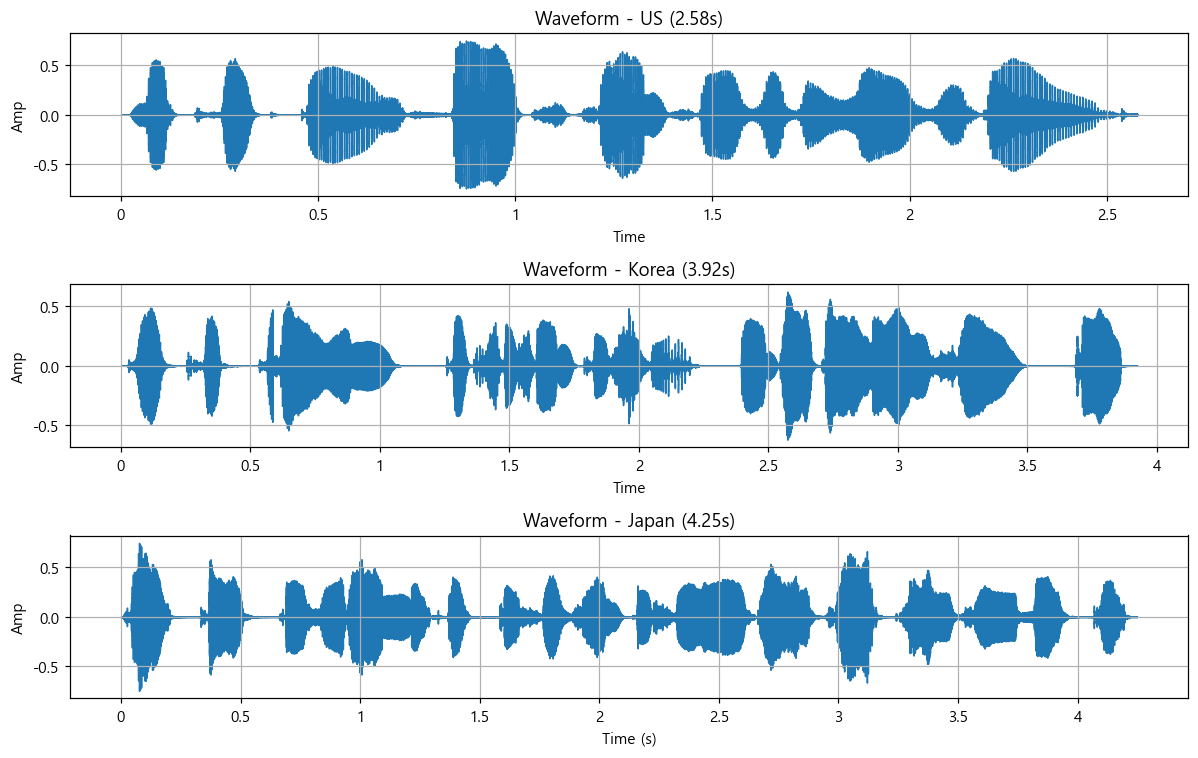

In [25]:
# ==============================
# 3. Waveform comparison
# ==============================
def plot_waveforms(signals, title_prefix="Waveform"):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.0*n + 1), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, (style, d) in zip(axes, signals.items()):
        librosa.display.waveshow(d["y"], sr=d["sr"], ax=ax)
        ax.set_title(f"{title_prefix} - {style} ({d['duration']:.2f}s)")
        ax.set_ylabel("Amp")
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_waveforms(signals)


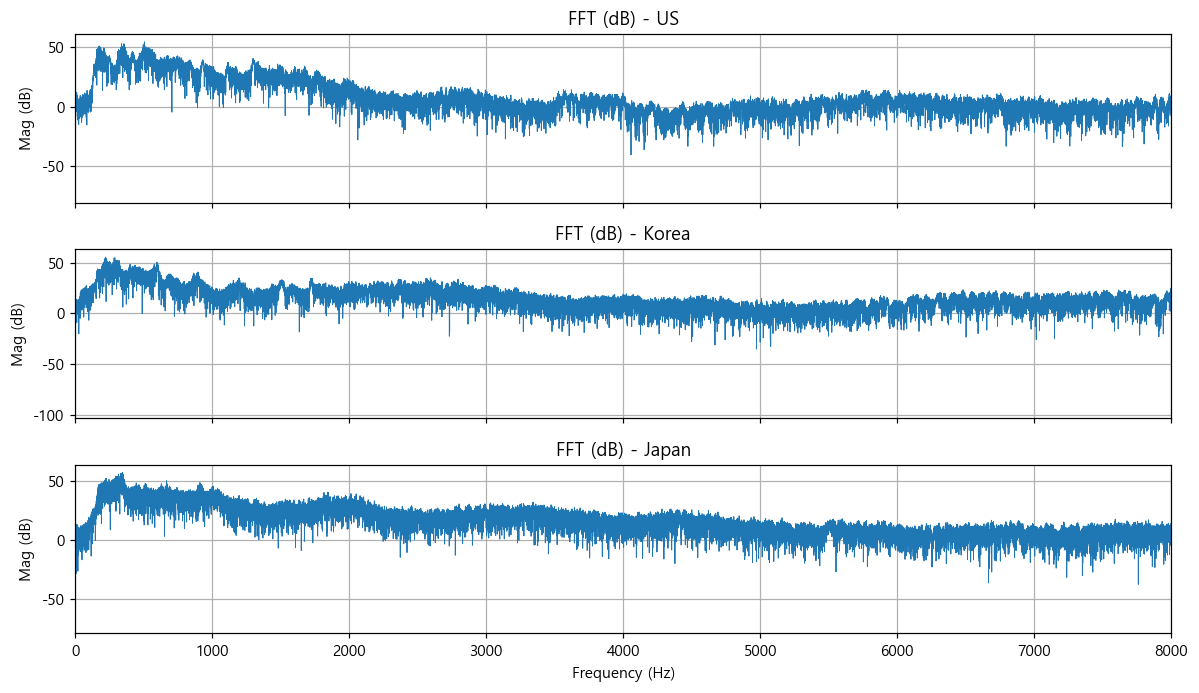

In [26]:
# ==============================
# 4. FFT magnitude spectrum (참고용 - 전체 평균)
# ==============================
def plot_fft_comparison(signals, max_freq=8000):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 1.8*n + 1), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, (style, d) in zip(axes, signals.items()):
        y, sr = d["y"], d["sr"]
        Y = np.fft.rfft(y)
        freqs = np.fft.rfftfreq(len(y), d=1/sr)
        mag = np.abs(Y)
        # dB 스케일이 읽기 쉬움
        mag_db = 20*np.log10(mag + 1e-6)
        ax.plot(freqs, mag_db, linewidth=0.6)
        ax.set_title(f"FFT (dB) - {style}")
        ax.set_ylabel("Mag (dB)")
        ax.set_xlim(0, max_freq)
    axes[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

plot_fft_comparison(signals)


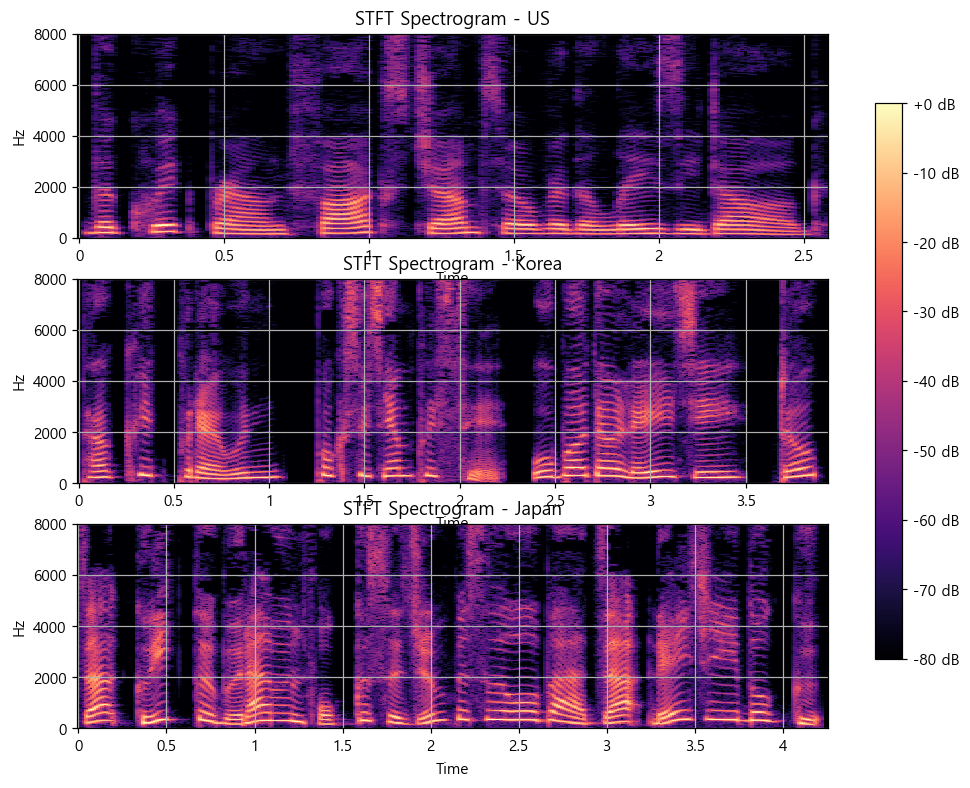

In [27]:
# ==============================
# 5. Spectrogram comparison (메인 분석 도구)
# ==============================
def plot_spectrograms(signals, max_freq=8000):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.4*n + 1), sharex=False)
    if n == 1:
        axes = [axes]
    last = None
    for ax, (style, d) in zip(axes, signals.items()):
        D = librosa.stft(d["y"], n_fft=n_fft, hop_length=hop_length, window="hann")
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        last = librosa.display.specshow(S_db, sr=d["sr"], hop_length=hop_length,
                                        x_axis="time", y_axis="hz", ax=ax)
        ax.set_ylim(0, max_freq)
        ax.set_title(f"STFT Spectrogram - {style}")
    fig.colorbar(last, ax=axes, format="%+2.0f dB", shrink=0.8)
    plt.show()

plot_spectrograms(signals)


## 3. Frame-level feature 분석 (1회 계산 후 캐싱)

전체 음성을 짧은 frame(약 12ms hop) 단위로 쪼개 시간에 따른 특징을 봅니다.
**pyin(피치 추정)은 느리므로 발음당 한 번만 계산하고 캐시**에 저장해 재사용합니다.

| feature | 의미 | accent에서 보는 것 |
|---|---|---|
| RMS energy | 구간별 소리 크기 | 강세 패턴 |
| Spectral centroid | 주파수 무게중심 | 자음 선명도 / 밝기 |
| ZCR | 영점 교차율 | 무성자음·마찰음 |
| Pitch (F0) | 기본 주파수 | 억양 변화 |


In [28]:
# ==============================
# 6. Frame-level features (캐싱)
# ==============================
_feature_cache = {}

def get_features(style):
    '''style별로 한 번만 계산하고 캐시. y가 바뀌면 캐시 키도 바뀜.'''
    d = signals[style]
    key = (style, len(d["y"]))
    if key in _feature_cache:
        return _feature_cache[key]

    y, sr = d["y"], d["sr"]
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
    f0, voiced_flag, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"),
        frame_length=frame_length, hop_length=hop_length)
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

    feat = {"times": times, "rms": rms, "centroid": centroid,
            "zcr": zcr, "pitch": f0, "voiced_flag": voiced_flag}
    _feature_cache[key] = feat
    return feat

# 미리 모두 계산 (시간이 좀 걸림)
for style in signals:
    get_features(style)
print("features cached for:", list(signals.keys()))


features cached for: ['US', 'Korea', 'Japan']


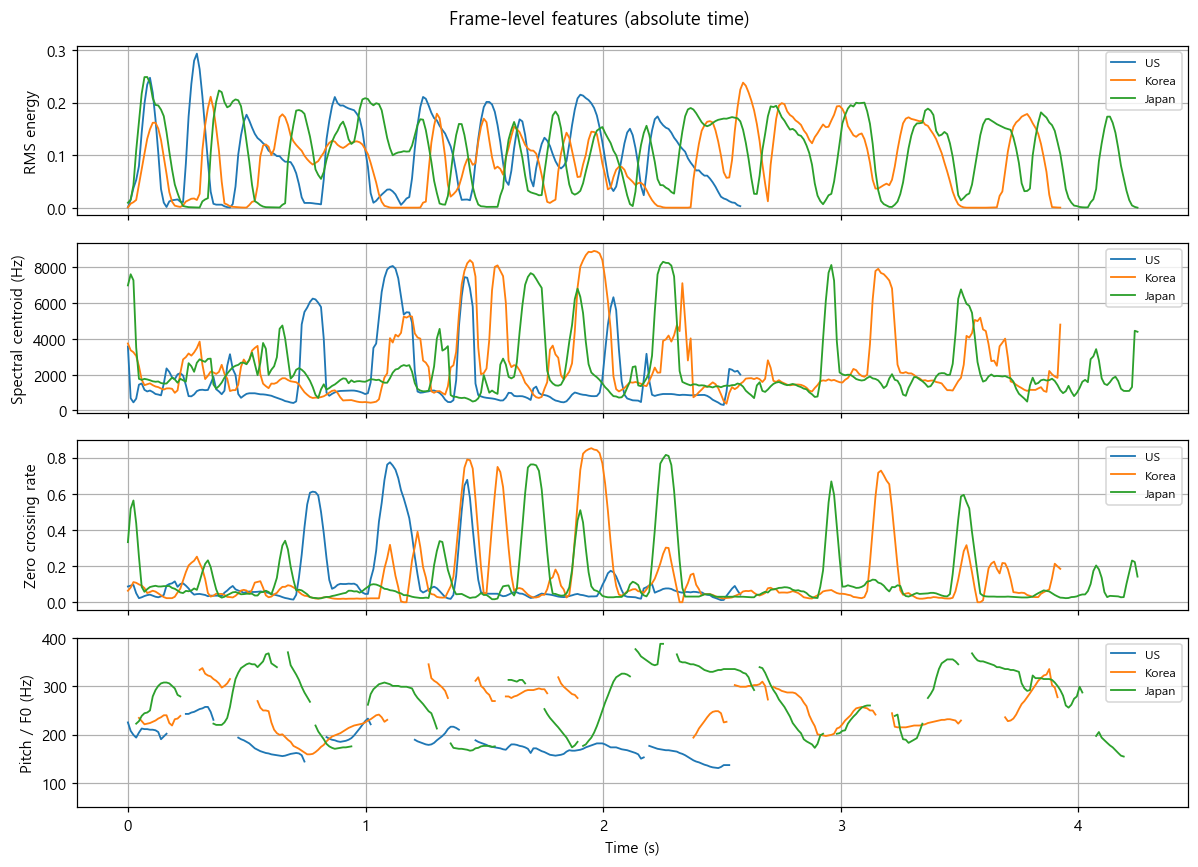

In [29]:
# ==============================
# 7. Frame-level features subplot (절대 시간축)
# ==============================
def plot_all_features(styles=None):
    styles = styles or list(signals.keys())
    specs = [("rms", "RMS energy", None),
             ("centroid", "Spectral centroid (Hz)", None),
             ("zcr", "Zero crossing rate", None),
             ("pitch", "Pitch / F0 (Hz)", (50, 400))]
    fig, axes = plt.subplots(len(specs), 1, figsize=(11, 8), sharex=True)
    for ax, (name, ylabel, ylim) in zip(axes, specs):
        for style in styles:
            f = get_features(style)
            ax.plot(f["times"], f[name], label=style, linewidth=1.2)
        ax.set_ylabel(ylabel)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time (s)")
    plt.suptitle("Frame-level features (absolute time)")
    plt.tight_layout()
    plt.show()

plot_all_features()


## 4. 시간 정규화 overlay 비교

나라별 길이가 다르므로(예: 일본식이 미국식보다 길다), 시간축을 **0~1로 정규화**해서
같은 발화 위치끼리 겹쳐 비교합니다. 이러면 "어느 단어 즈음에서 피치/에너지가 어떻게 다른지"를
길이 차이에 방해받지 않고 볼 수 있습니다.


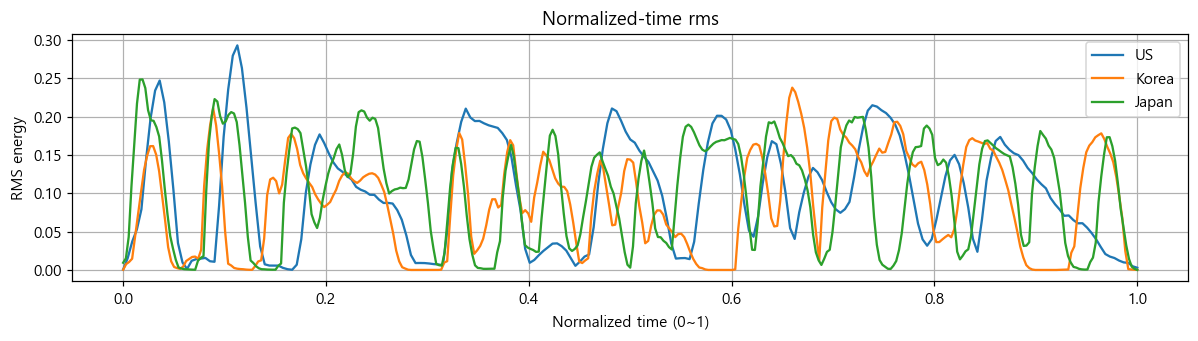

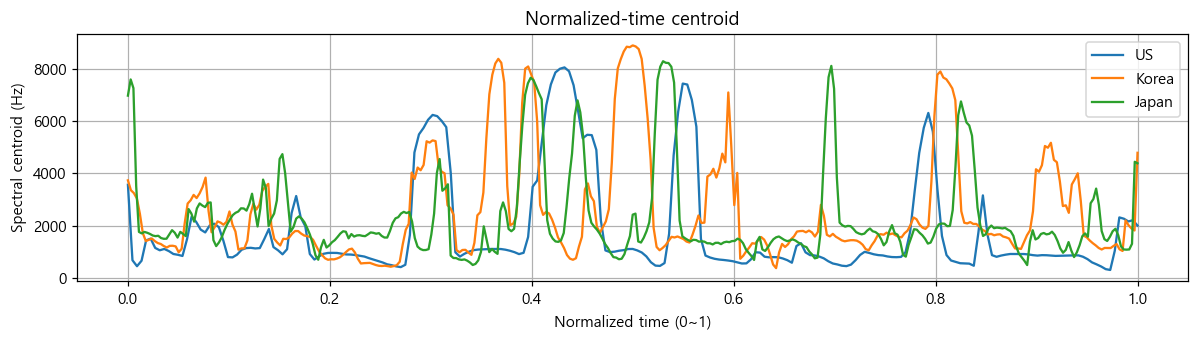

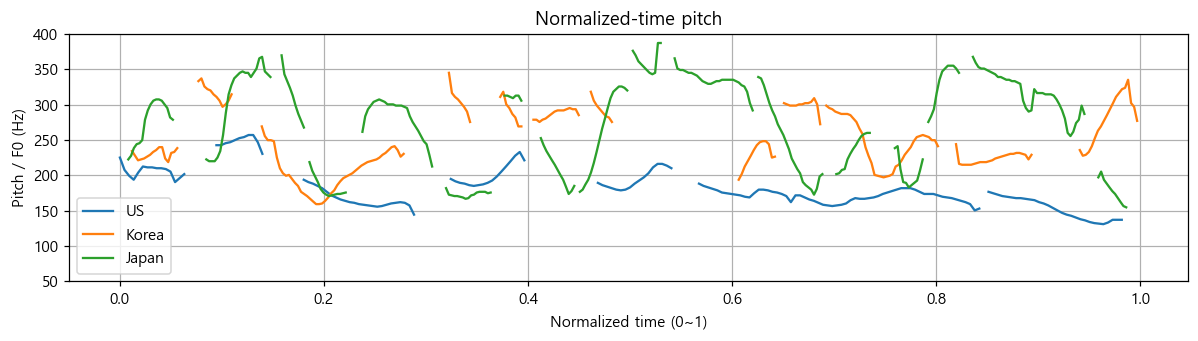

In [30]:
# ==============================
# 8. Normalized-time overlay
# ==============================
def plot_normalized(feature_name, ylabel=None, ylim=None):
    plt.figure(figsize=(11, 3.2))
    for style in signals:
        f = get_features(style)
        t = f["times"]
        t_norm = t / t[-1] if t[-1] > 0 else t   # 0~1 정규화
        plt.plot(t_norm, f[feature_name], label=style, linewidth=1.5)
    plt.title(f"Normalized-time {feature_name}")
    plt.xlabel("Normalized time (0~1)")
    plt.ylabel(ylabel or feature_name)
    if ylim: plt.ylim(*ylim)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_normalized("rms", "RMS energy")
plot_normalized("centroid", "Spectral centroid (Hz)")
plot_normalized("pitch", "Pitch / F0 (Hz)", ylim=(50, 400))


## 5. 자동 구간분할 (Energy-based segmentation)

**손으로 단어 시간을 적지 않습니다.** RMS 에너지가 임계값을 넘는 연속 구간을
하나의 "발화 덩어리(segment)"로 자동 검출합니다.
파일이 바뀌어도 코드를 고칠 필요가 없습니다.

> 원리: week10 자료의 RMS 기반 묵음/발화 구분과 같은 아이디어입니다.
> `top_db` 와 `min_dur` 만 조절하면 분할 민감도를 바꿀 수 있습니다.


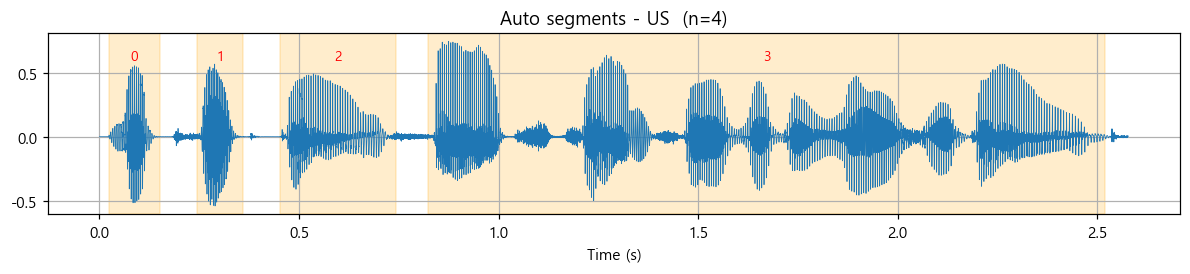

US: 4 segments -> ['0.02-0.15', '0.24-0.36', '0.45-0.74', '0.82-2.52']


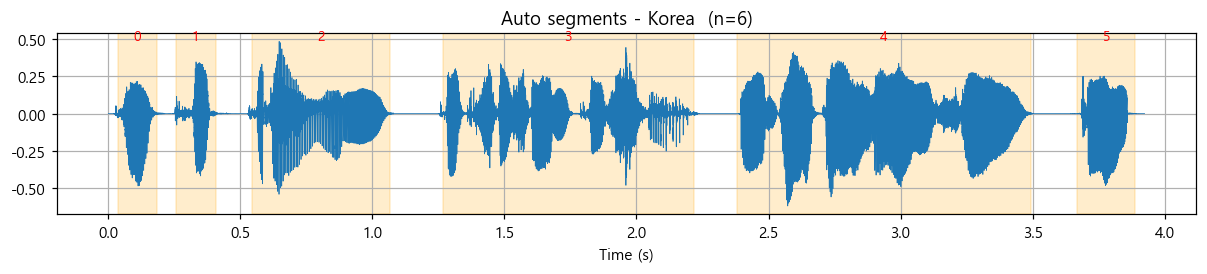

Korea: 6 segments -> ['0.03-0.19', '0.26-0.41', '0.55-1.07', '1.27-2.22', '2.38-3.49', '3.67-3.89']


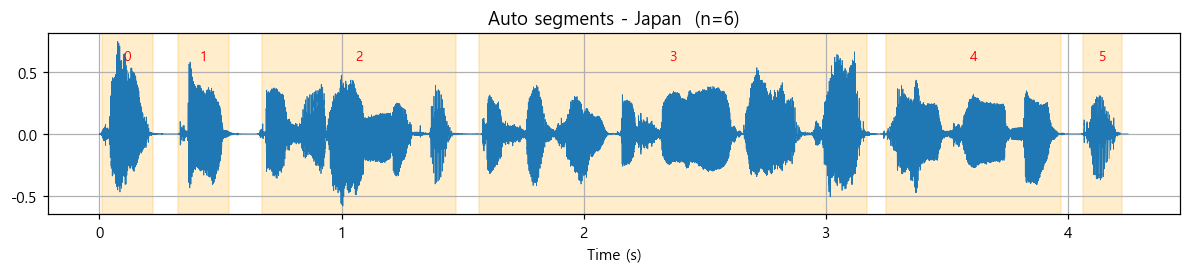

Japan: 6 segments -> ['0.01-0.22', '0.33-0.53', '0.67-1.47', '1.57-3.17', '3.25-3.97', '4.06-4.23']


In [31]:
# ==============================
# 9. Auto segmentation by energy
# ==============================
def auto_segments(style, top_db=25, min_dur=0.06, merge_gap=0.05):
    '''RMS 에너지 기반으로 발화 구간 [(start, end), ...] 자동 검출.
    top_db: 최대 에너지 대비 이만큼 아래는 묵음 취급
    min_dur: 이보다 짧은 구간은 버림 (초)
    merge_gap: 이보다 가까운 두 구간은 합침 (초)
    '''
    d = signals[style]
    y, sr = d["y"], d["sr"]
    # librosa.effects.split: 비묵음 구간을 샘플 인덱스로 반환
    intervals = librosa.effects.split(y, top_db=top_db,
                                      frame_length=frame_length, hop_length=hop_length)
    segs = [(s/sr, e/sr) for s, e in intervals]

    # 가까운 구간 병합
    merged = []
    for s, e in segs:
        if merged and s - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))
    # 너무 짧은 구간 제거
    merged = [(s, e) for s, e in merged if (e - s) >= min_dur]
    return merged

# 검출 + 시각화
def plot_segments(style, top_db=25, min_dur=0.06, merge_gap=0.05):
    d = signals[style]
    y, sr = d["y"], d["sr"]
    segs = auto_segments(style, top_db, min_dur, merge_gap)
    t = np.arange(len(y)) / sr

    plt.figure(figsize=(11, 2.6))
    plt.plot(t, y, linewidth=0.5)
    for i, (s, e) in enumerate(segs):
        plt.axvspan(s, e, alpha=0.2, color="orange")
        plt.text((s+e)/2, np.max(np.abs(y))*0.8, str(i),
                 ha="center", fontsize=9, color="red")
    plt.title(f"Auto segments - {style}  (n={len(segs)})")
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
    return segs

segments_by_style = {}
for style in signals:
    segments_by_style[style] = plot_segments(style, top_db=25)
    print(f"{style}: {len(segments_by_style[style])} segments ->",
          [f"{s:.2f}-{e:.2f}" for s, e in segments_by_style[style]])


## 6. 특정 단어 정밀 분석 (자동 구간에 라벨 부여)

위 자동 분할 그림에서 각 구간에 **번호**가 붙어 있습니다.
그 번호를 보고 원하는 단어에 라벨만 매핑하면, 단어별 정밀 분석을 할 수 있습니다.

> 자동 분할은 "단어"가 아니라 "에너지 덩어리"라 단어와 1:1로 안 맞을 수 있습니다.
> 그래서 (a) 자동 구간 번호로 라벨을 붙이거나, (b) 미세 조정이 필요하면 시간을 직접 넣을 수도 있게
> 두 방식을 모두 지원합니다. **기본은 자동 구간 번호 방식**입니다.


In [32]:
# ==============================
# 10. 단어 라벨 매핑
# ==============================
# 위 9번 그림의 구간 번호를 보고 원하는 단어만 매핑하세요.
# 형식: { style: { "word": segment_index, ... } }
# 예시 (실제 번호는 본인 그림을 보고 수정!):
word_label_map = {
    "US":    {"think": 1, "signal": 2, "project": 4, "interesting": 6},
    "Korea": {"think": 1, "signal": 2, "project": 4, "interesting": 6},
    "Japan": {"think": 1, "signal": 2, "project": 4, "interesting": 6},
}

# (선택) 자동 구간이 부정확할 때만 쓰는 수동 오버라이드. 비워두면 무시됨.
# 형식: { style: { "word": (start_sec, end_sec) } }
word_manual_override = {
    # "Japan": {"interesting": (3.0, 3.9)},
}

def get_word_interval(style, word):
    '''수동 오버라이드가 있으면 그것을, 없으면 자동 구간 번호로 (start,end) 반환.'''
    if style in word_manual_override and word in word_manual_override[style]:
        return word_manual_override[style][word]
    idx = word_label_map[style][word]
    segs = segments_by_style[style]
    if idx >= len(segs):
        raise IndexError(f"{style}: segment index {idx} 없음 (총 {len(segs)}개). 그림 보고 수정하세요.")
    return segs[idx]

def crop(style, start, end):
    d = signals[style]
    return d["y"][int(start*d["sr"]):int(end*d["sr"])]


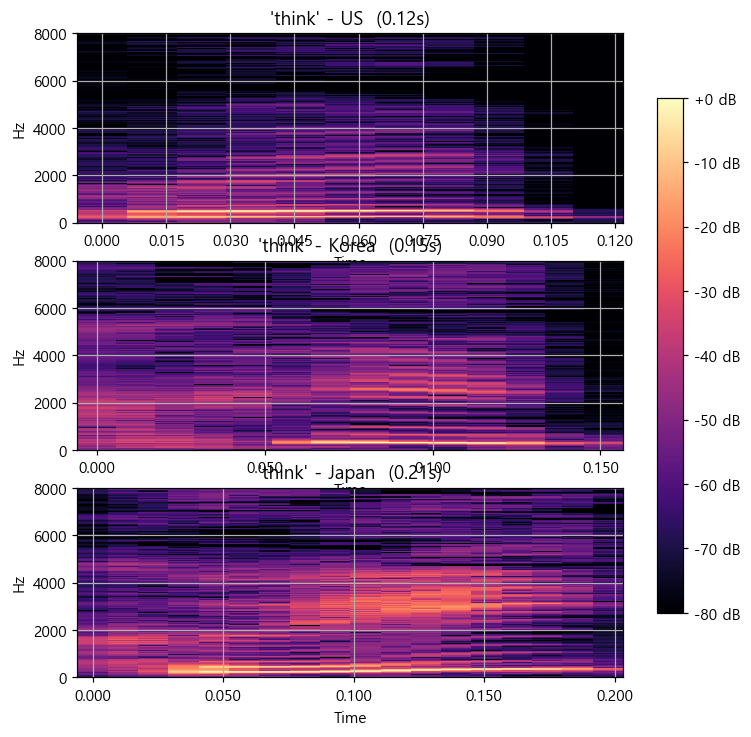

IndexError: US: segment index 6 없음 (총 4개). 그림 보고 수정하세요.

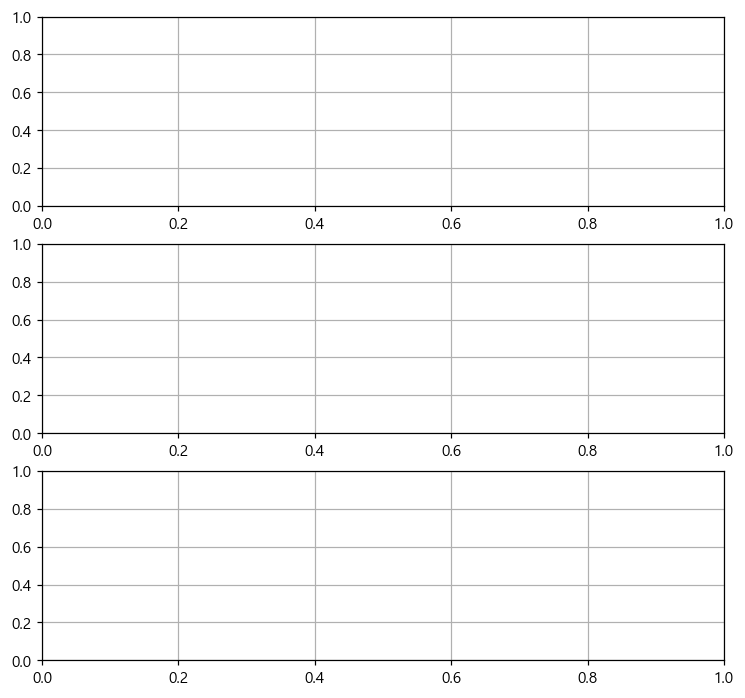

In [33]:
# ==============================
# 11. 단어별 spectrogram 비교
# ==============================
def plot_word_spectrograms(word, max_freq=8000):
    styles = list(signals.keys())
    fig, axes = plt.subplots(len(styles), 1, figsize=(8, 2.2*len(styles)+1))
    if len(styles) == 1: axes = [axes]
    last = None
    for ax, style in zip(axes, styles):
        s, e = get_word_interval(style, word)
        yw = crop(style, s, e)
        D = librosa.stft(yw, n_fft=n_fft, hop_length=hop_length)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        last = librosa.display.specshow(S_db, sr=signals[style]["sr"],
                                        hop_length=hop_length, x_axis="time",
                                        y_axis="hz", ax=ax)
        ax.set_ylim(0, max_freq)
        ax.set_title(f"'{word}' - {style}  ({e-s:.2f}s)")
    fig.colorbar(last, ax=axes, format="%+2.0f dB", shrink=0.8)
    plt.show()

# 분석하고 싶은 단어 (라벨 매핑한 것 중에서)
for w in ["think", "interesting"]:
    plot_word_spectrograms(w)


In [34]:
# ==============================
# 12. 단어별 feature 요약 테이블
# ==============================
def word_summary(style, word):
    s, e = get_word_interval(style, word)
    yw = crop(style, s, e)
    sr = signals[style]["sr"]
    rms = librosa.feature.rms(y=yw, frame_length=frame_length, hop_length=hop_length)[0]
    cen = librosa.feature.spectral_centroid(y=yw, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(yw, frame_length=frame_length, hop_length=hop_length)[0]
    return {"style": style, "word": word, "dur": e-s,
            "mean_rms": float(np.mean(rms)),
            "mean_centroid": float(np.mean(cen)),
            "mean_zcr": float(np.mean(zcr))}

rows = []
for style in signals:
    for word in word_label_map[style]:
        try:
            rows.append(word_summary(style, word))
        except IndexError as ex:
            print("skip:", ex)
df_words = pd.DataFrame(rows)
df_words


skip: US: segment index 4 없음 (총 4개). 그림 보고 수정하세요.
skip: US: segment index 6 없음 (총 4개). 그림 보고 수정하세요.
skip: Korea: segment index 6 없음 (총 6개). 그림 보고 수정하세요.
skip: Japan: segment index 6 없음 (총 6개). 그림 보고 수정하세요.


,style,word,dur,mean_rms,mean_centroid,mean_zcr
0,US,think,0.116100,0.164866,1171.534000,0.037997
1,US,signal,0.290249,0.102243,1179.249918,0.053861
2,Korea,think,0.150930,0.090073,2561.449333,0.112514
3,Korea,signal,0.522449,0.111187,1069.504195,0.038021
4,Korea,project,1.114558,0.130762,2104.306475,0.096116
5,Japan,think,0.208980,0.153299,2305.963266,0.070204
6,Japan,signal,0.801088,0.121870,1707.134043,0.071233
7,Japan,project,0.719819,0.114372,2103.100706,0.094370


## 7. MFCC 비교

MFCC는 성도(vocal tract) 모양 = 발음의 음색을 요약합니다 (수업자료 슬라이드 9~10).
발음 스타일 간 평균 MFCC 벡터의 거리로 "얼마나 다른지"를 수치화합니다.


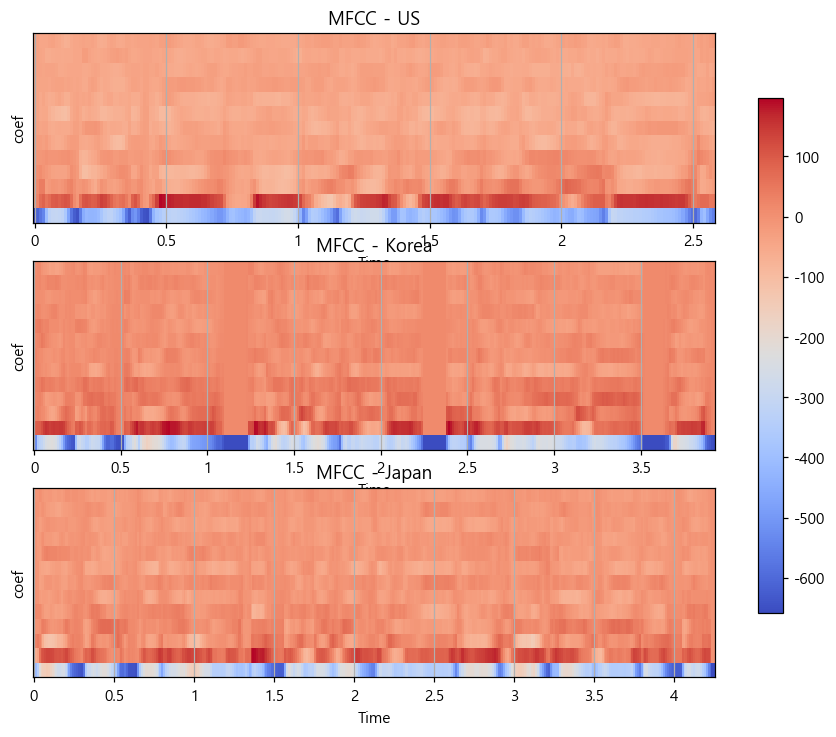

             pair   distance
0     US vs Korea  63.234840
1     US vs Japan  65.282784
2  Korea vs Japan  54.906937


In [35]:
# ==============================
# 13. MFCC heatmap + 거리
# ==============================
def plot_mfccs(signals_dict):
    n = len(signals_dict)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2*n+1))
    if n == 1: axes = [axes]
    last = None
    mfcc_means = {}
    for ax, (style, d) in zip(axes, signals_dict.items()):
        mfcc = librosa.feature.mfcc(y=d["y"], sr=d["sr"], n_mfcc=13,
                                    n_fft=n_fft, hop_length=hop_length)
        mfcc_means[style] = mfcc.mean(axis=1)
        last = librosa.display.specshow(mfcc, sr=d["sr"], hop_length=hop_length,
                                        x_axis="time", ax=ax)
        ax.set_title(f"MFCC - {style}")
        ax.set_ylabel("coef")
    fig.colorbar(last, ax=axes, shrink=0.8)
    plt.show()
    return mfcc_means

mfcc_means = plot_mfccs(signals)

# 쌍별 거리
styles = list(mfcc_means.keys())
dist_rows = []
for i in range(len(styles)):
    for j in range(i+1, len(styles)):
        a, b = styles[i], styles[j]
        dist_rows.append({"pair": f"{a} vs {b}",
                          "distance": float(np.linalg.norm(mfcc_means[a]-mfcc_means[b]))})
df_dist = pd.DataFrame(dist_rows)
print(df_dist)


## 8. 변환 실험: 한국식/일본식 → 미국식

**완전한 accent conversion이 아닙니다.** 신호처리로 다음 두 가지만 조작합니다:

1. **Time stretch** — 발화 길이를 미국식 길이에 맞춤 (한국식·일본식이 더 느린 경향)
2. **High-frequency boost** — 고주파를 키워 자음 선명도를 높임

변환 전후를 waveform / spectrogram / feature로 비교합니다.
이 방식의 **한계**도 함께 기록합니다 (보고서 '실패 분석' 항목).


In [36]:
# ==============================
# 14. 변환 함수
# ==============================
def high_frequency_boost(y, sr, cutoff=3000, boost=1.4):
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    gain = np.ones_like(freqs)
    gain[freqs >= cutoff] = boost
    yb = np.fft.irfft(Y * gain, n=len(y))
    m = np.max(np.abs(yb))
    if m > 0:
        yb = yb / m * 0.9
    return yb

def convert_to_us_style(src_style, target_style="US", cutoff=3000, boost=1.4):
    y = signals[src_style]["y"]
    sr = signals[src_style]["sr"]
    src_dur = signals[src_style]["duration"]
    tgt_dur = signals[target_style]["duration"]
    # time_stretch: rate>1 이면 짧아짐. src가 길면 rate>1 이 되어 짧아짐.
    rate = src_dur / tgt_dur
    y_fast = librosa.effects.time_stretch(y, rate=rate)
    y_conv = high_frequency_boost(y_fast, sr, cutoff=cutoff, boost=boost)
    return y_conv, sr, rate

# 한국식, 일본식 둘 다 변환
converted = {}
for src in ["Korea", "Japan"]:
    yc, sr, rate = convert_to_us_style(src)
    converted[src] = {"y": yc, "sr": sr, "duration": len(yc)/sr, "rate": rate,
                      "filename": f"{src}_to_US.wav"}
    print(f"{src}: stretch rate={rate:.3f}  -> new dur={len(yc)/sr:.3f}s "
          f"(target US={signals['US']['duration']:.3f}s)")


Korea: stretch rate=1.523  -> new dur=2.577s (target US=2.577s)
Japan: stretch rate=1.649  -> new dur=2.577s (target US=2.577s)


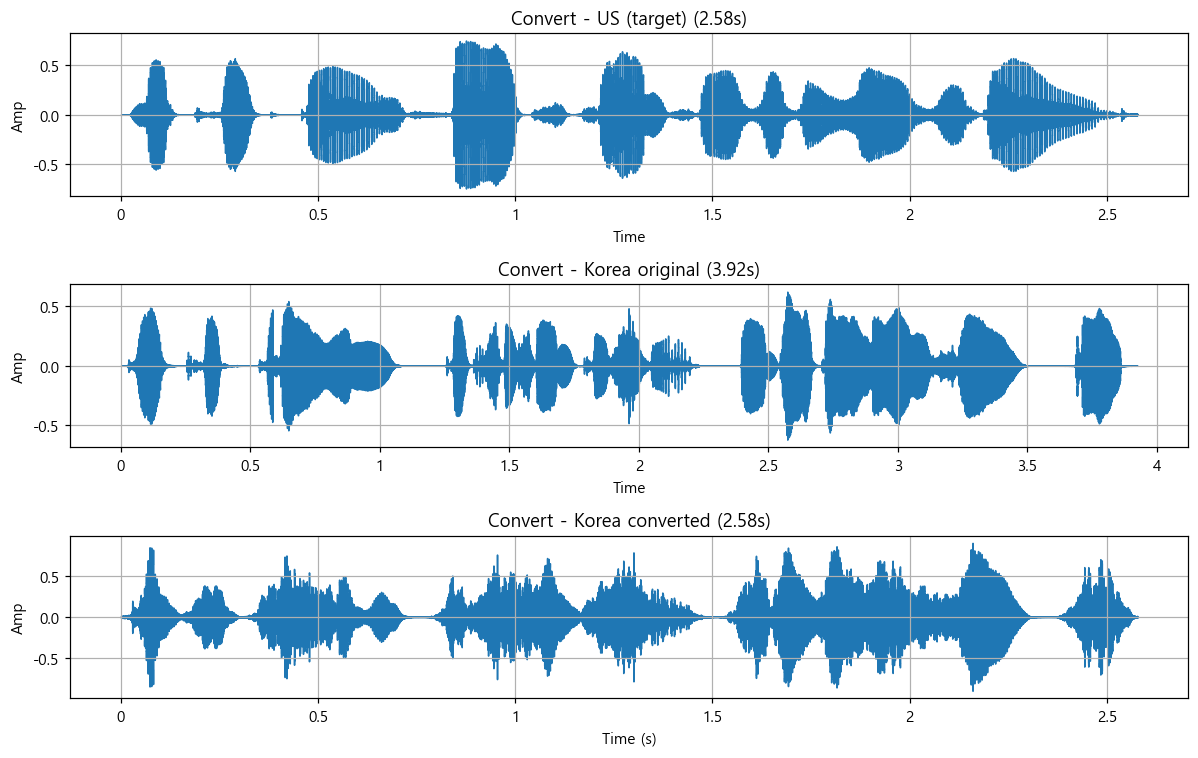

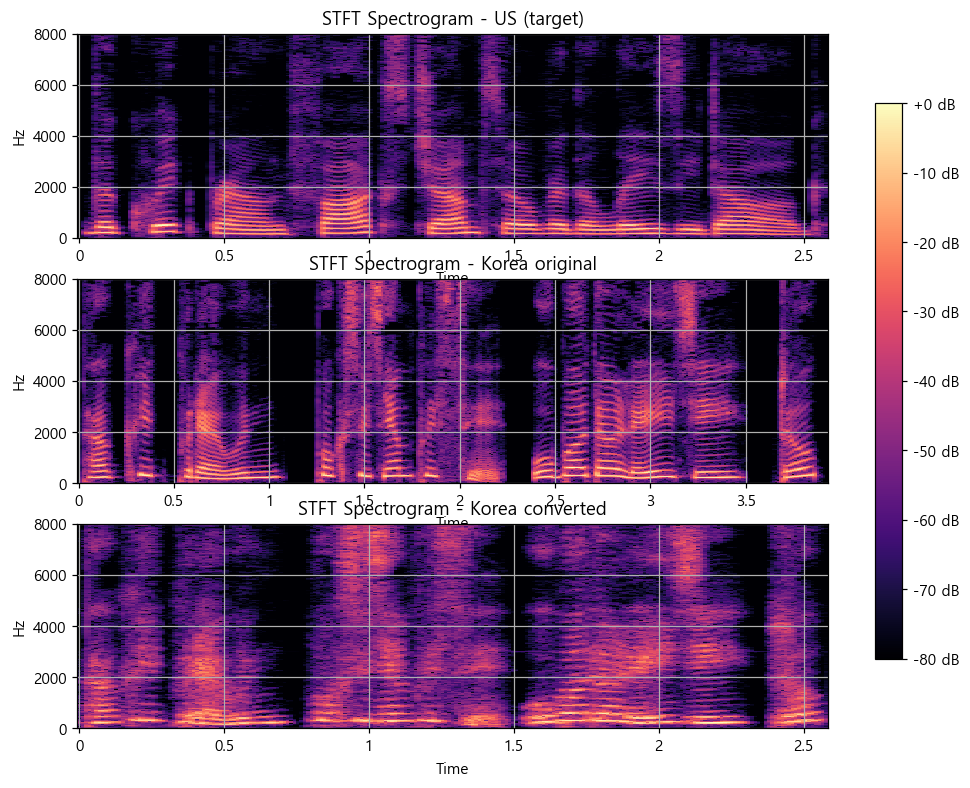

In [37]:
# ==============================
# 15. 변환 전후 비교 (한국식 예시)
# ==============================
src = "Korea"   # "Japan" 으로 바꿔서 둘 다 보기
compare = {
    "US (target)":      signals["US"],
    f"{src} original":  signals[src],
    f"{src} converted": converted[src],
}
plot_waveforms(compare, title_prefix="Convert")
plot_spectrograms(compare)


In [38]:
# ==============================
# 16. 변환 결과 저장 (들어볼 수 있게)
# ==============================
import soundfile as sf

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
for src, d in converted.items():
    p = os.path.join(OUTPUT_DIR, d["filename"])
    sf.write(p, d["y"], d["sr"])
    print("saved:", p)

# 노트북에서 바로 듣기
from IPython.display import Audio, display
for src, d in converted.items():
    print(f"--- {src} converted ---")
    display(Audio(d["y"], rate=d["sr"]))


saved: ./output\Korea_to_US.wav
saved: ./output\Japan_to_US.wav
--- Korea converted ---


--- Japan converted ---


## 9. 한계 및 실패 분석 (보고서용)

이 변환 실험이 "진짜 미국식 발음"이 되지 못하는 이유 — 보고서의 **실패 분석(10점)** 에 활용하세요.

1. **Time stretch는 속도만 바꾼다.** 발화 길이는 맞춰지지만, 한국식·일본식 특유의
   **모음 삽입**(예: "project" → "프로젝트"처럼 자음 뒤에 모음이 붙는 것)이나
   **자음 대체**(th → s/z 등)는 그대로 남습니다. 이건 음소(phoneme) 차원의 문제라
   단순 신호처리로는 해결 불가.
2. **High-frequency boost는 음색만 밝게 한다.** 자음이 또렷해 보일 수 있지만,
   잘못된 위치의 자음을 강조하면 오히려 부자연스러워집니다. 또 잡음도 같이 증폭됩니다.
3. **Time stretch 과다 시 음질 저하.** rate가 1에서 많이 벗어나면 phase vocoder 아티팩트
   (금속성 소리)가 들립니다. 길이 차이가 큰 일본식에서 더 두드러집니다.
4. **자동 구간분할의 한계.** 연음(linking)이 심하면 두 단어가 한 덩어리로 묶이거나,
   약한 자음에서 한 단어가 둘로 쪼개집니다. 그래서 단어 라벨 매핑이 필요했습니다.

### 개선 방향 (+α 에 쓸 거리)
- 포먼트(formant) 분석을 추가해 모음 차이를 정량화 (LPC 기반)
- DTW(Dynamic Time Warping)로 길이 다른 두 발음을 정렬해 단어 단위 자동 정합
- WORLD / pyworld 보코더로 피치·스펙트럼 envelope를 분리 변환


## 10. 최종 제출 체크리스트

- [ ] `target_files` 를 **직접 녹음한 3개 파일**로 교체했는가 (Papago 저장본은 개발용)
- [ ] 9번 자동분할 그림을 보고 `word_label_map` 의 구간 번호를 **내 파일에 맞게** 수정했는가
- [ ] FFT spectrum + spectrogram 결과가 보고서에 포함됐는가 (요구사항)
- [ ] 변환 실험 결과(전/후 비교)와 한계 분석이 포함됐는가
- [ ] 보고서 5페이지 이내, 맑은고딕 12pt, 그림 크기 적당히
- [ ] 마감: 6/5 23:59
